In [47]:
import pandas as pd
url = "https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/penguins_cleaned.csv"

df = pd.read_csv(url)
df.head(1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male


In [48]:
import scipy.stats as stats

r, p = stats.pearsonr(df["body_mass_g"], df["bill_length_mm"])
r2 = r**2

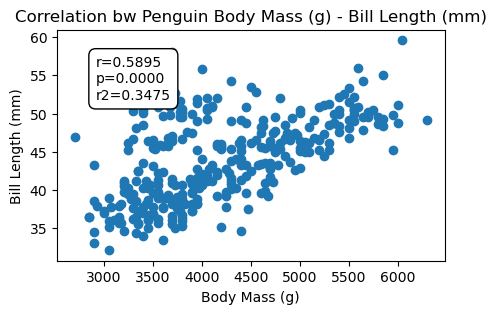

In [49]:
# create a scatter plot with matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
text = f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""

plt.scatter(df["body_mass_g"], df["bill_length_mm"])
plt.xlabel("Body Mass (g)")
plt.ylabel("Bill Length (mm)")
plt.text(
    0.1,
    0.7,
    text,
    transform=plt.gca().transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc": "white"}
)
plt.title("Correlation bw Penguin Body Mass (g) - Bill Length (mm)")
plt.show()


r = 0.58 means a moderately positive correlation which means as x goes up, so does y

p-value = below 0.5 means r is statistically significant
(low chance its a false positive - fail to reject Ho)

r2 = y is 34% dependent by the movement in x -- 34% of y movmeent is explained by x

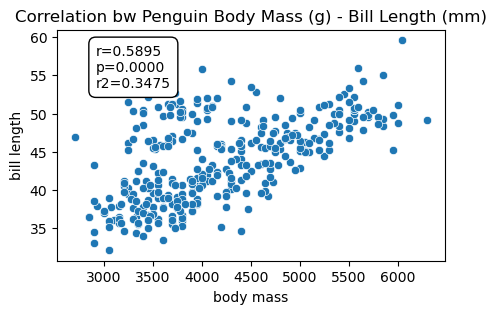

In [50]:
# do the same as above with seaborn

import seaborn as sns

plt.figure(figsize=(5,3))
scat = sns.scatterplot(data=df, x = "body_mass_g", y = "bill_length_mm")
scat.text(
    0.1,
    0.75,
    text,
    transform=scat.transAxes,
    bbox={"boxstyle":"round, pad=0.5", "fc": "white"},
)
scat.set(xlabel="body mass", ylabel="bill length", title="Correlation bw Penguin Body Mass (g) - Bill Length (mm)")

plt.show()

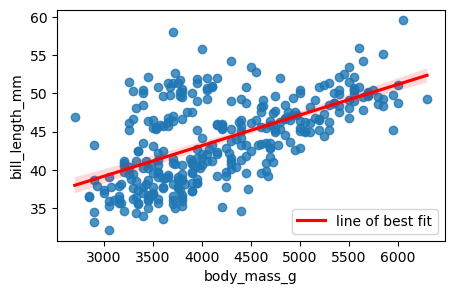

In [51]:
plt.figure(figsize=(5,3))
reg = sns.regplot(
    data=df, 
    x="body_mass_g", 
    y="bill_length_mm",
    line_kws={"color":"red", "label": "line of best fit"}
    )
plt.legend()

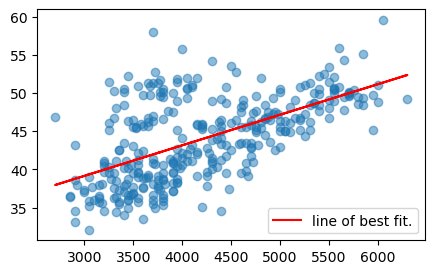

In [52]:
x = df["body_mass_g"]
y = df["bill_length_mm"]

m, b, r_val, p_val, err = stats.linregress(df["body_mass_g"], df["bill_length_mm"])
# y = m(x) + b

line = m * df["body_mass_g"] + b

plt.figure(figsize=(5,3))
plt.scatter(x, y, alpha=0.5)
plt.plot(x, line, color="red", label="line of best fit.") # add line
plt.legend()
plt.show()

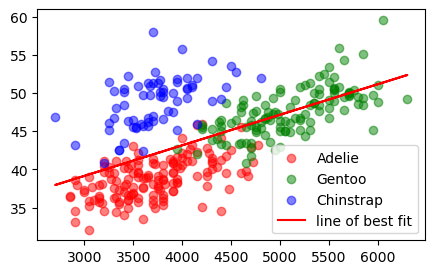

In [53]:
plt.figure(figsize=(5,3))
colors = ["red", "green", "blue"]
for species in df["species"].unique():
    subset = df.loc[df["species"] == species]
    x1 = subset["body_mass_g"]
    y1 = subset["bill_length_mm"]
    plt.scatter(x1,y1, alpha=0.5, label = species, color = colors.pop(0))
plt.plot(x,line,color="red", label = "line of best fit")
plt.legend()
plt.show()

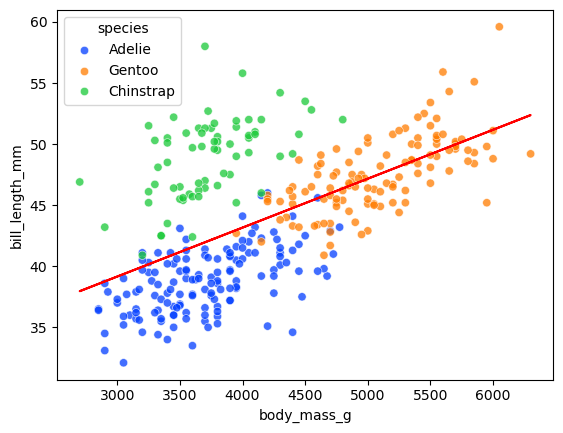

In [56]:
x_str = "body_mass_g"
y_str = "bill_length_mm"
scat = sns.scatterplot(
    data=df, 
    x=x_str,
    y=y_str,
    hue="species",
    alpha = 0.75,
    palette="bright")
plt.plot(x, line, color="red")

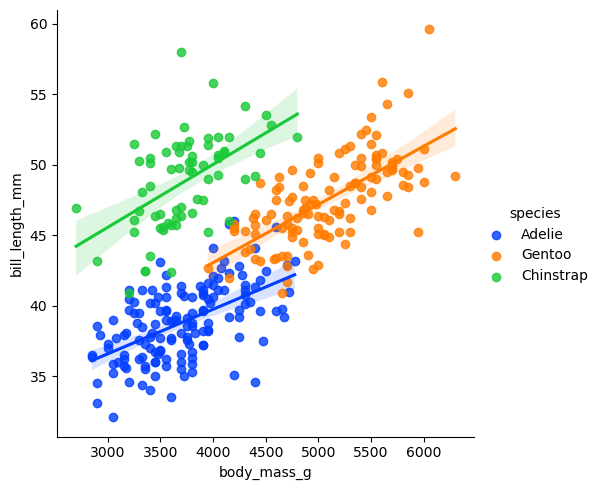

In [58]:
lm = sns.lmplot(
    data=df,
    x=x_str,
    y=y_str,
    hue="species",
    palette="bright"
)

<Figure size 500x300 with 0 Axes>

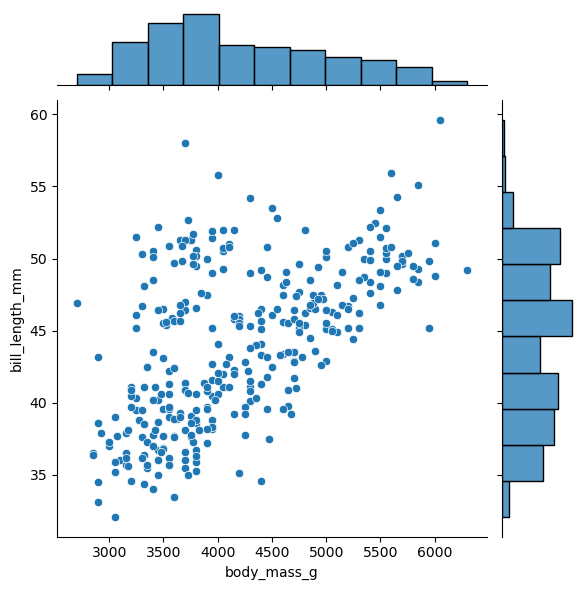

In [59]:
plt.figure(figsize=(5,3))
sns.jointplot(
    data=df,
    x=x_str,
    y=y_str,
)